In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [5]:
df = pd.read_csv("/content/hotstar.csv")

print(df.head())
print(df.info())
print(df.describe())

   hotstar_id                                title  \
0  1000087439                Sambha - Aajcha Chawa   
1  1260023113  Cars Toon: Mater And The Ghostlight   
2  1260103188                Kanmani Rambo Khatija   
3  1260126754                            Butterfly   
4  1260018228                           Sister Act   

                                         description      genre  year  \
0  A young man sets off on a mission to clean up ...     Action  2012   
1  Mater is haunted by a mysterious blue light th...  Animation  2006   
2  Unlucky since birth, Rambo finds hope when he ...    Romance  2022   
3  While trying to rescue her sister's kids from ...   Thriller  2022   
4  Rene, a lounge singer, decides to stay at a Ch...     Comedy  1992   

  age_rating  running_time  seasons  episodes   type  
0    U/A 16+         141.0      NaN       NaN  movie  
1          U           7.0      NaN       NaN  movie  
2    U/A 16+         157.0      NaN       NaN  movie  
3    U/A 16+    

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
hotstar_id         0
title              0
description        0
genre              0
year               0
age_rating         0
running_time    2306
seasons         4568
episodes        4568
type               0
dtype: int64


In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [10]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

     hotstar_id  title  description  genre    year  age_rating  running_time  \
0  1.000087e+09   4980          916      0  2012.0           4         141.0   
1  1.260023e+09   1115         3833      3  2006.0           2           7.0   
2  1.260103e+09   2882         6131     26  2022.0           4         157.0   
3  1.260127e+09   1073         6671     35  2022.0           4         136.0   
4  1.260018e+09   5268         4591      6  1992.0           5         100.0   

   seasons  episodes  type  
0      1.0      22.0     0  
1      1.0      22.0     0  
2      1.0      22.0     0  
3      1.0      22.0     0  
4      1.0      22.0     0  


In [11]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

   hotstar_id  title  description  genre      year  age_rating  running_time  \
0   -0.122580   4980          916      0  0.023571           4      0.887439   
1    0.417566   1115         3833      3 -0.479108           2     -2.373649   
2    0.417733   2882         6131     26  0.861371           4      1.276822   
3    0.417782   1073         6671     35  0.861371           4      0.765756   
4    0.417556   5268         4591      6 -1.652028           5     -0.110357   

    seasons  episodes  type  
0 -0.187839 -0.224367     0  
1 -0.187839 -0.224367     0  
2 -0.187839 -0.224367     0  
3 -0.187839 -0.224367     0  
4 -0.187839 -0.224367     0  


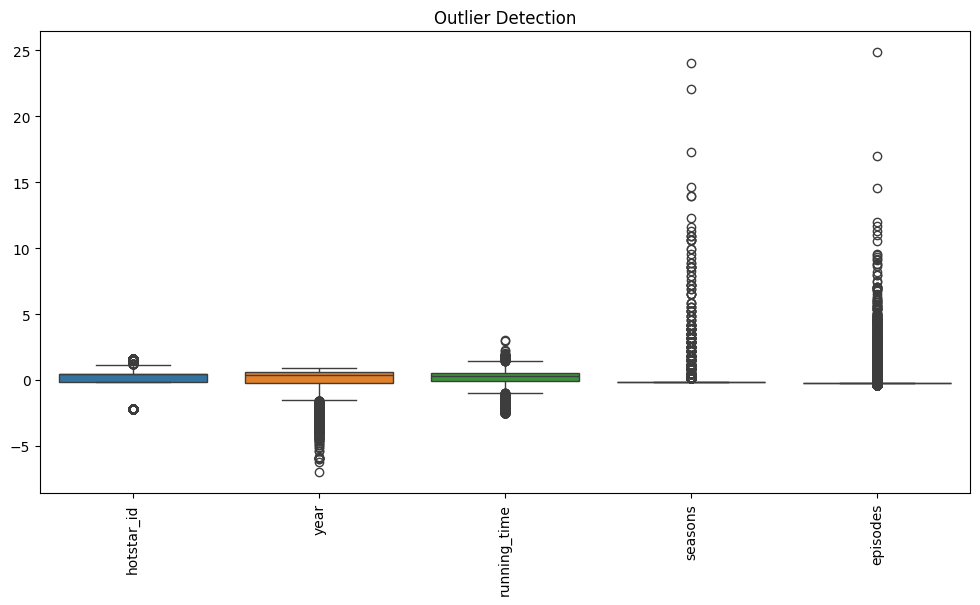

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [13]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
    ~((df[num_cols] < (Q1 - 1.5 * IQR)) |
      (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Original Shape :", df.shape)
print("After Removing Outliers :", df_clean.shape)

Original Shape : (6874, 10)
After Removing Outliers : (2389, 10)


In [18]:
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=['number']).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Standardization Completed")
print(df.head())

Standardization Completed
   hotstar_id     title  description     genre      year  age_rating  \
0   -0.122580  0.852106    -1.269825 -1.397995  0.023571    0.708935   
1    0.417566 -1.156557     0.211322 -1.103889 -0.479108   -0.980808   
2    0.417733 -0.238237     1.378164  1.150925  0.861371    0.708935   
3    0.417782 -1.178384     1.652356  2.033243  0.861371    0.708935   
4    0.417556  1.001781     0.596207 -0.809783 -1.652028    1.553806   

   running_time   seasons  episodes      type  
0      0.887439 -0.187839 -0.224367 -0.710504  
1     -2.373649 -0.187839 -0.224367 -0.710504  
2      1.276822 -0.187839 -0.224367 -0.710504  
3      0.765756 -0.187839 -0.224367 -0.710504  
4     -0.110357 -0.187839 -0.224367 -0.710504  


In [19]:
df.to_csv("jiohotstar_cleaned.csv", index=False)

print("Dataset preprocessing completed successfully!")
print("Final Shape:", df.shape)

print(df.head())

Dataset preprocessing completed successfully!
Final Shape: (6874, 10)
   hotstar_id     title  description     genre      year  age_rating  \
0   -0.122580  0.852106    -1.269825 -1.397995  0.023571    0.708935   
1    0.417566 -1.156557     0.211322 -1.103889 -0.479108   -0.980808   
2    0.417733 -0.238237     1.378164  1.150925  0.861371    0.708935   
3    0.417782 -1.178384     1.652356  2.033243  0.861371    0.708935   
4    0.417556  1.001781     0.596207 -0.809783 -1.652028    1.553806   

   running_time   seasons  episodes      type  
0      0.887439 -0.187839 -0.224367 -0.710504  
1     -2.373649 -0.187839 -0.224367 -0.710504  
2      1.276822 -0.187839 -0.224367 -0.710504  
3      0.765756 -0.187839 -0.224367 -0.710504  
4     -0.110357 -0.187839 -0.224367 -0.710504  


In [14]:
df_clean.to_csv("jiohotstar_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
